In [1]:
import time
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 在这里统一设置全局超时时间（当前：600.0 秒）
TIMEOUT_LIMIT = 600.0
# ==========================================

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'graph_coloring_core.py').exists() and (NOTEBOOK_DIR / 'code' / 'graph_coloring_core.py').exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / 'code'
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from graph_coloring_core import GraphColoringSolver as _CoreGraphColoringSolver
from graph_coloring_core import load_dimacs_graph as _core_load_dimacs_graph

results_archive = {}

def load_dimacs_graph(filepath):
    path = Path(filepath)
    if not path.is_absolute():
        candidate = NOTEBOOK_DIR / filepath
        if candidate.exists():
            path = candidate
    return _core_load_dimacs_graph(str(path))

class GraphColoringSolver(_CoreGraphColoringSolver):
    def __init__(self, adj_list, num_colors):
        super().__init__(adj_list, num_colors)

    def solve(self, config):
        success, backtracks, duration, timeout_flag, overhead_ms = super().solve(config, timeout=TIMEOUT_LIMIT)
        return success, backtracks, duration, overhead_ms

limit_desc = '无时间限制' if TIMEOUT_LIMIT is None else f'{TIMEOUT_LIMIT}s'
print(f'实验引擎已就绪（当前超时阈值：{limit_desc}）')


实验引擎已就绪（当前超时阈值：600.0s）


In [2]:
# ---  V0 ---
cfg = {'name': 'V0_Base', 'fc': False, 'mrv': False, 'degree': False, 'lcv': False, 'symmetry': True}
datasets = {'le450_5a.col': 5, 'le450_15b.col': 15, 'le450_25a.col': 25}
results_archive[cfg['name']] = []

for filename, limit in datasets.items():
    adj = load_dimacs_graph(filename)
    solver = GraphColoringSolver(adj, limit)
    _, bt, dur, oh = solver.solve(cfg)
    results_archive[cfg['name']].append({'bt': bt, 'dur': dur, 'oh': oh})
    print(f"[{cfg['name']}] 数据集 {filename} | 耗时: {dur:.4f}s | 回溯: {bt} | Overhead: {oh:.4f} ms")

[V0_Base] 数据集 le450_5a.col | 耗时: 600.0010s | 回溯: 50614939 | Overhead: 0.0119 ms
[V0_Base] 数据集 le450_15b.col | 耗时: 600.0087s | 回溯: 21500493 | Overhead: 0.0279 ms
[V0_Base] 数据集 le450_25a.col | 耗时: 600.0162s | 回溯: 11578423 | Overhead: 0.0518 ms


In [ ]:
# ---  V1 ---
cfg = {'name': 'V1_Base_FC', 'fc': True, 'mrv': False, 'degree': False, 'lcv': False, 'symmetry': True}
datasets = {'le450_5a.col': 5, 'le450_15b.col': 15, 'le450_25a.col': 25}
results_archive[cfg['name']] = []

for filename, limit in datasets.items():
    adj = load_dimacs_graph(filename)
    solver = GraphColoringSolver(adj, limit)
    _, bt, dur, oh = solver.solve(cfg)
    results_archive[cfg['name']].append({'bt': bt, 'dur': dur, 'oh': oh})
    print(f"[{cfg['name']}] 数据集 {filename} | 耗时: {dur:.4f}s | 回溯: {bt} | Overhead: {oh:.4f} ms")

[V1_Base_FC] 数据集 le450_5a.col | 耗时: 600.0019s | 回溯: 29863621 | Overhead: 0.0201 ms


In [ ]:
# ---  V2 ---
cfg = {'name': 'V2_Base_FC_MRV', 'fc': True, 'mrv': True, 'degree': False, 'lcv': False, 'symmetry': True}
datasets = {'le450_5a.col': 5, 'le450_15b.col': 15, 'le450_25a.col': 25}
results_archive[cfg['name']] = []

for filename, limit in datasets.items():
    adj = load_dimacs_graph(filename)
    solver = GraphColoringSolver(adj, limit)
    _, bt, dur, oh = solver.solve(cfg)
    results_archive[cfg['name']].append({'bt': bt, 'dur': dur, 'oh': oh})
    print(f"[{cfg['name']}] 数据集 {filename} | 耗时: {dur:.4f}s | 回溯: {bt} | Overhead: {oh:.4f} ms")

[V2_Base_FC_MRV] 数据集 le450_5a.col | 耗时: 179.9141s | 回溯: 1412111 | Overhead: 0.1274 ms
[V2_Base_FC_MRV] 数据集 le450_15b.col | 耗时: 600.0148s | 回溯: 8259865 | Overhead: 0.0726 ms
[V2_Base_FC_MRV] 数据集 le450_25a.col | 耗时: 0.0469s | 回溯: 450 | Overhead: 0.1043 ms


In [ ]:
# ---  V3 ---
cfg = {'name': 'V3_Base_FC_MRV_LCV', 'fc': True, 'mrv': True, 'degree': False, 'lcv': True, 'symmetry': True}
datasets = {'le450_5a.col': 5, 'le450_15b.col': 15, 'le450_25a.col': 25}
results_archive[cfg['name']] = []

for filename, limit in datasets.items():
    adj = load_dimacs_graph(filename)
    solver = GraphColoringSolver(adj, limit)
    _, bt, dur, oh = solver.solve(cfg)
    results_archive[cfg['name']].append({'bt': bt, 'dur': dur, 'oh': oh})
    print(f"[{cfg['name']}] 数据集 {filename} | 耗时: {dur:.4f}s | 回溯: {bt} | Overhead: {oh:.4f} ms")

[V3_Base_FC_MRV_LCV] 数据集 le450_5a.col | 耗时: 205.9691s | 回溯: 1715797 | Overhead: 0.1200 ms
[V3_Base_FC_MRV_LCV] 数据集 le450_15b.col | 耗时: 600.0156s | 回溯: 9873689 | Overhead: 0.0608 ms
[V3_Base_FC_MRV_LCV] 数据集 le450_25a.col | 耗时: 0.0708s | 回溯: 450 | Overhead: 0.1573 ms


In [ ]:
# ---  V4 ---
cfg = {'name': 'V4_Base_FC_MRV_Degree', 'fc': True, 'mrv': True, 'degree': True, 'lcv': False, 'symmetry': True}
datasets = {'le450_5a.col': 5, 'le450_15b.col': 15, 'le450_25a.col': 25}
results_archive[cfg['name']] = []

for filename, limit in datasets.items():
    adj = load_dimacs_graph(filename)
    solver = GraphColoringSolver(adj, limit)
    _, bt, dur, oh = solver.solve(cfg)
    results_archive[cfg['name']].append({'bt': bt, 'dur': dur, 'oh': oh})
    print(f"[{cfg['name']}] 数据集 {filename} | 耗时: {dur:.4f}s | 回溯: {bt} | Overhead: {oh:.4f} ms")

[V4_Base_FC_MRV_Degree] 数据集 le450_5a.col | 耗时: 10.3723s | 回溯: 65132 | Overhead: 0.1592 ms
[V4_Base_FC_MRV_Degree] 数据集 le450_15b.col | 耗时: 600.0152s | 回溯: 11764851 | Overhead: 0.0510 ms
[V4_Base_FC_MRV_Degree] 数据集 le450_25a.col | 耗时: 0.0528s | 回溯: 450 | Overhead: 0.1174 ms


In [ ]:
# ---  V5 ---
cfg = {'name': 'V5_Base_FC_MRV_Degree_LCV', 'fc': True, 'mrv': True, 'degree': True, 'lcv': True, 'symmetry': True}
datasets = {'le450_5a.col': 5, 'le450_15b.col': 15, 'le450_25a.col': 25}
results_archive[cfg['name']] = []

for filename, limit in datasets.items():
    adj = load_dimacs_graph(filename)
    solver = GraphColoringSolver(adj, limit)
    _, bt, dur, oh = solver.solve(cfg)
    results_archive[cfg['name']].append({'bt': bt, 'dur': dur, 'oh': oh})
    print(f"[{cfg['name']}] 数据集 {filename} | 耗时: {dur:.4f}s | 回溯: {bt} | Overhead: {oh:.4f} ms")

[V5_Base_FC_MRV_Degree_LCV] 数据集 le450_5a.col | 耗时: 7.1313s | 回溯: 45406 | Overhead: 0.1571 ms
[V5_Base_FC_MRV_Degree_LCV] 数据集 le450_15b.col | 耗时: 600.0158s | 回溯: 7240070 | Overhead: 0.0829 ms
[V5_Base_FC_MRV_Degree_LCV] 数据集 le450_25a.col | 耗时: 0.1388s | 回溯: 450 | Overhead: 0.3085 ms


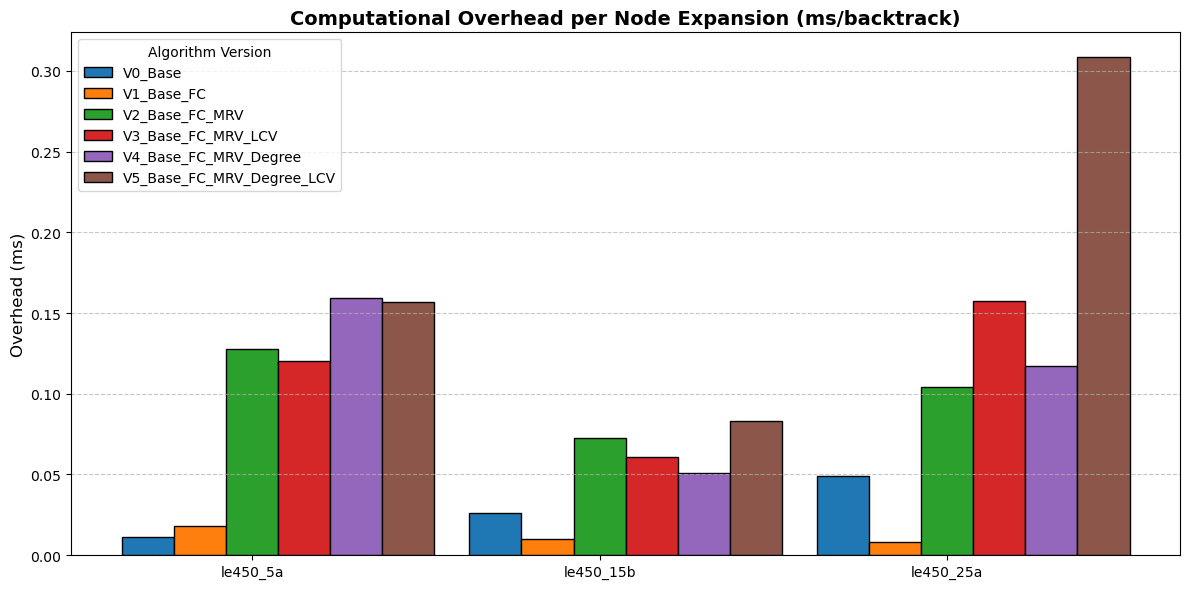

In [ ]:
# ================= v0-v5对比单次节点开销 =================
labels = ['le450_5a', 'le450_15b', 'le450_25a']
x = np.arange(len(labels))
width = 0.15
fig, ax = plt.subplots(figsize=(12, 6))

for i, (algo_name, stats) in enumerate(results_archive.items()):
    overheads = [s['oh'] for s in stats]
    ax.bar(x + i*width, overheads, width, label=algo_name, edgecolor='black')

ax.set_title('Computational Overhead per Node Expansion (ms/backtrack)', fontsize=14, fontweight='bold')
ax.set_ylabel('Overhead (ms)', fontsize=12)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(labels)
ax.legend(title="Algorithm Version")
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# ================= 补充 Cell: 运行纯回溯 Baseline =================
cfg_base = {'name': 'Baseline', 'fc': False, 'mrv': False, 'degree': False, 'lcv': False, 'symmetry': False}
datasets = {'le450_5a.col': 5, 'le450_15b.col': 15, 'le450_25a.col': 25}

# 确保字典中存在该 key
if 'Baseline' not in results_archive:
    results_archive['Baseline'] = []

print(f"========== 正在运行 纯回溯 {cfg_base['name']} ==========")
for filename, limit in datasets.items():
    adj = load_dimacs_graph(filename)
    solver = GraphColoringSolver(adj, limit)
    _, bt, dur, oh = solver.solve(cfg_base)
    results_archive[cfg_base['name']].append({'bt': bt, 'dur': dur, 'oh': oh})
    
    if dur > solver.timeout:
        print(f"[{cfg_base['name']}] 数据集 {filename} | 结果: 超时 (>{solver.timeout}s) | 回溯: {bt}+")
    else:
        print(f"[{cfg_base['name']}] 数据集 {filename} | 耗时: {dur:.4f}s | 回溯: {bt} | Overhead: {oh:.4f} ms")

========== 正在运行 纯回溯 Baseline ==========


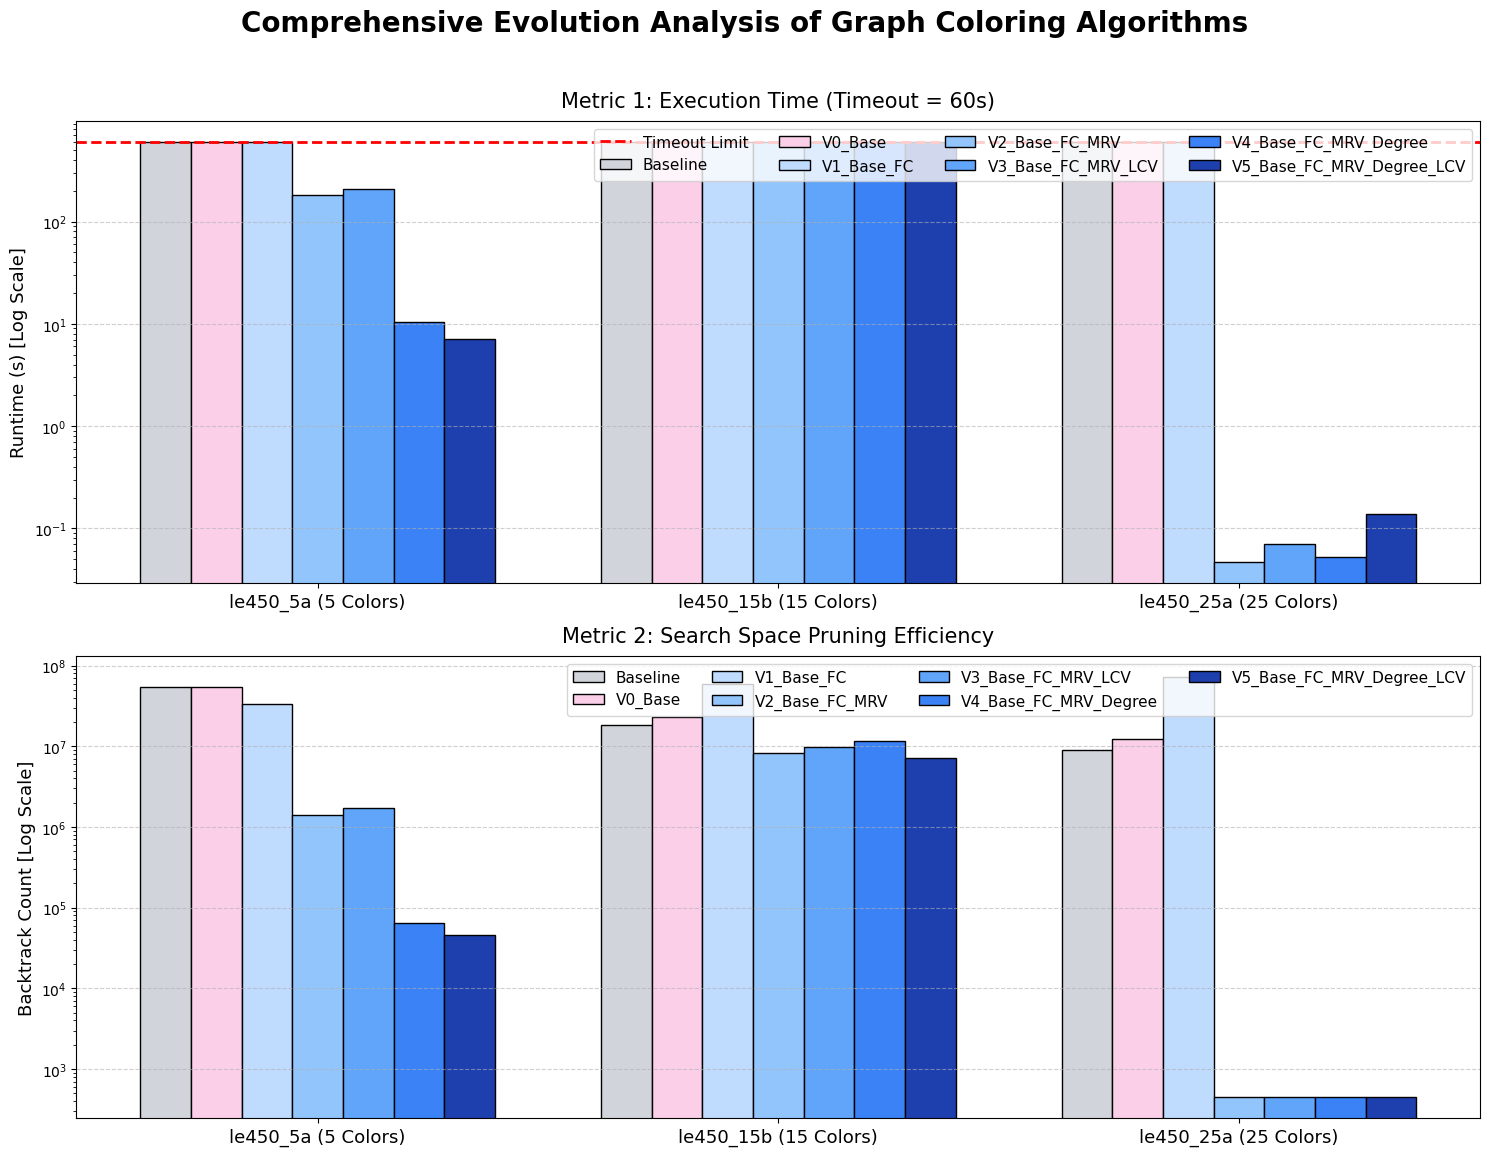

In [ ]:
# ================= 终极绘图 Cell: 核心双维度全景对比 =================
import numpy as np
import matplotlib.pyplot as plt

# 严格匹配你刚刚跑出来的变量名
ordered_algos = [
    'Baseline', 
    'V0_Base', 
    'V1_Base_FC', 
    'V2_Base_FC_MRV', 
    'V3_Base_FC_MRV_LCV', 
    'V4_Base_FC_MRV_Degree', 
    'V5_Base_FC_MRV_Degree_LCV'
]
labels = ['le450_5a (5 Colors)', 'le450_15b (15 Colors)', 'le450_25a (25 Colors)']
x = np.arange(len(labels))
width = 0.11
TIMEOUT = TIMEOUT_LIMIT

colors = ['#d1d5db', '#fbcfe8', '#bfdbfe', '#93c5fd', '#60a5fa', '#3b82f6', '#1e40af']

# 改为 2 行 1 列，调整图片高度让柱子更清晰
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
fig.suptitle('Comprehensive Evolution Analysis of Graph Coloring Algorithms', fontsize=20, fontweight='bold', y=0.96)

def get_metric_list(algo, metric_key):
    if algo not in results_archive or len(results_archive[algo]) == 0:
        return [0.001, 0.001, 0.001]
    vals = [item[metric_key] for item in results_archive[algo]]
    if metric_key in ['dur', 'bt']:
        return [max(v, 0.0001) for v in vals]
    return vals

# ================= 1. 执行耗时对比 (Log Scale) =================
multiplier = 0
for i, algo in enumerate(ordered_algos):
    offset = width * multiplier
    durs = get_metric_list(algo, 'dur')
    display_durs = [min(d, TIMEOUT) for d in durs] 
    ax1.bar(x + offset, display_durs, width, label=algo, color=colors[i], edgecolor='black')
    multiplier += 1

ax1.set_ylabel('Runtime (s) [Log Scale]', fontsize=13)
ax1.set_title('Metric 1: Execution Time (Timeout = ' + str(TIMEOUT) + ' s)', fontsize=15, pad=10)
ax1.set_xticks(x + width * 3)
ax1.set_xticklabels(labels, fontsize=13)
ax1.set_yscale('log')
ax1.axhline(y=TIMEOUT, color='red', linestyle='--', linewidth=2, label='Timeout Limit')
ax1.legend(loc='upper right', ncol=4, fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# ================= 2. 回溯次数对比 (Log Scale) =================
multiplier = 0
for i, algo in enumerate(ordered_algos):
    offset = width * multiplier
    bts = get_metric_list(algo, 'bt')
    ax2.bar(x + offset, bts, width, label=algo, color=colors[i], edgecolor='black')
    multiplier += 1

ax2.set_ylabel('Backtrack Count [Log Scale]', fontsize=13)
ax2.set_title('Metric 2: Search Space Pruning Efficiency', fontsize=15, pad=10)
ax2.set_xticks(x + width * 3)
ax2.set_xticklabels(labels, fontsize=13)
ax2.set_yscale('log')
ax2.legend(loc='upper right', ncol=4, fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(f'Final_Evolution_Comparison_{TIMEOUT}.png', dpi=300)
plt.show()